# 05 — PySpark EDA & Visualizations

Large-scale exploratory analysis using native PySpark operation , including a broadcast join demonstration, followed by
matplotlib/seaborn charts converted from Spark only at the final step.


In [1]:
import os, sys
os.environ['PYSPARK_PYTHON'] = sys.executable
os.environ['HADOOP_HOME'] = r'C:\Hadoop'

In [2]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
import warnings
warnings.filterwarnings("ignore")

spark = SparkSession.builder.appName("BusBunching_05_EDA").master("local[4]").config("spark.ui.showConsoleProgress", "false").getOrCreate()
spark.sparkContext.setLogLevel("ERROR")

location_clean = spark.read.option("header", True).option("inferSchema", True).csv("data/cleaned_locations.csv")
location_clean = location_clean.withColumn("line_ref", F.col("line_ref").cast("string"))
routes_headway = spark.read.option("header", True).option("inferSchema", True).csv(r"C:\Users\ACER\OneDrive\Documents\Big Data Programming Project Coursework\data\routes_scheduled_headway.csv")
routes_headway = routes_headway.withColumn("line_ref", F.col("line_ref").cast("string"))

location_clean.printSchema()


root
 |-- poll_timestamp: timestamp (nullable = true)
 |-- recorded_at_time: timestamp (nullable = true)
 |-- line_ref: string (nullable = true)
 |-- vehicle_ref: string (nullable = true)
 |-- operator_ref: string (nullable = true)
 |-- latitude: double (nullable = true)
 |-- longitude: double (nullable = true)
 |-- bearing: integer (nullable = true)



root
 |-- poll_timestamp: timestamp (nullable = true)
 |-- recorded_at_time: timestamp (nullable = true)
 |-- line_ref: string (nullable = true)
 |-- vehicle_ref: string (nullable = true)
 |-- operator_ref: string (nullable = true)
 |-- latitude: double (nullable = true)
 |-- longitude: double (nullable = true)
 |-- bearing: integer (nullable = true)



## 5.1 Statistical summary (PySpark `.describe()`)

In [5]:
location_clean.describe(["latitude", "longitude"]).show()


+-------+------------------+-------------------+
|summary|          latitude|          longitude|
+-------+------------------+-------------------+
|  count|               762|                762|
|   mean|48.321675509186356|-2.6305352887139093|
| stddev|16.335680692650374|   0.91713385833873|
|    min|               0.0|          -3.590221|
|    max|         54.995464|                0.0|
+-------+------------------+-------------------+



## 5.3 Statistical measures — mean, median, std, skewness, kurtosis

In [6]:
# Recompute a quick observed-headway column here for EDA-level statistics
# (the full labeled version with the bunching threshold lives in Notebook 03 — this is exploratory only)
from pyspark.sql.window import Window
_w = Window.partitionBy("line_ref").orderBy("recorded_at_time")
_eda_headway = location_clean.withColumn(
    "prev_time", F.lag("recorded_at_time").over(_w)
).withColumn(
    "headway_sec", F.unix_timestamp("recorded_at_time") - F.unix_timestamp("prev_time")
).dropna(subset=["headway_sec"])

_eda_headway.select(
    F.mean("headway_sec").alias("mean_headway"),
    F.expr("percentile_approx(headway_sec, 0.5)").alias("median_headway"),
    F.stddev("headway_sec").alias("stddev_headway"),
    F.skewness("headway_sec").alias("skewness_headway"),
    F.kurtosis("headway_sec").alias("kurtosis_headway"),
).show()


+------------------+--------------+-----------------+-----------------+------------------+
|      mean_headway|median_headway|   stddev_headway| skewness_headway|  kurtosis_headway|
+------------------+--------------+-----------------+-----------------+------------------+
|3232.7764165390504|           788|6442.423280330148|3.179540960977617|11.046264708626788|
+------------------+--------------+-----------------+-----------------+------------------+



## 5.4 Outlier detection (IQR method) on observed headway

In [7]:
quantiles = _eda_headway.approxQuantile("headway_sec", [0.25, 0.75], 0.01)
q1, q3 = quantiles[0], quantiles[1]
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

print(f"Q1: {q1}, Q3: {q3}, IQR: {iqr}")
print(f"Outlier bounds: [{lower_bound}, {upper_bound}]")

outliers = _eda_headway.filter(
    (F.col("headway_sec") < lower_bound) | (F.col("headway_sec") > upper_bound)
)
print("Outlier count:", outliers.count(), "out of", _eda_headway.count())
# Note: an unusually LOW headway outlier is itself a strong bunching signal — cross-check
# these rows against the is_bunching label produced in Notebook 03.


Q1: 20.0, Q3: 2601.0, IQR: 2581.0
Outlier bounds: [-3851.5, 6472.5]
Outlier count: 96 out of 653


Outlier count: 96 out of 653


## 5.5 Data profiling — null counts and cardinality

In [8]:
from pyspark.sql.functions import col, count, when

null_counts = location_clean.select([
    count(when(col(c).isNull(), c)).alias(c) for c in location_clean.columns
])
null_counts.show()

print("Distinct routes:", location_clean.select("line_ref").distinct().count())
print("Distinct vehicles:", location_clean.select("vehicle_ref").distinct().count())


+--------------+----------------+--------+-----------+------------+--------+---------+-------+
|poll_timestamp|recorded_at_time|line_ref|vehicle_ref|operator_ref|latitude|longitude|bearing|
+--------------+----------------+--------+-----------+------------+--------+---------+-------+
|             0|               0|       0|          0|           0|       0|        0|      0|
+--------------+----------------+--------+-----------+------------+--------+---------+-------+

Distinct routes: 109
Distinct vehicles: 528


Distinct routes: 109


Distinct vehicles: 528


## 5.6 GroupBy/agg exploration + broadcast join demonstration

In [9]:
per_route = location_clean.groupBy("line_ref").agg(
    F.count("*").alias("n_pings"),
    F.countDistinct("vehicle_ref").alias("n_vehicles")
)

# Broadcast join: routes_headway is small, so we broadcast it to avoid a costly shuffle join
per_route_enriched = per_route.join(
    F.broadcast(routes_headway.select("line_ref", "scheduled_headway_sec")),
    on="line_ref", how="left"
).orderBy(F.desc("n_pings"))

per_route_enriched.explain()  # confirms BroadcastHashJoin in the physical plan
per_route_enriched.show()


== Physical Plan ==
AdaptiveSparkPlan isFinalPlan=false
+- Sort [n_pings#847L DESC NULLS LAST], true, 0
   +- Exchange rangepartitioning(n_pings#847L DESC NULLS LAST, 200), ENSURE_REQUIREMENTS, [plan_id=810]
      +- Project [line_ref#62, n_pings#847L, n_vehicles#848L, scheduled_headway_sec#105]
         +- BroadcastHashJoin [line_ref#62], [line_ref#103], LeftOuter, BuildRight, false
            :- HashAggregate(keys=[line_ref#62], functions=[count(1), count(distinct vehicle_ref#63)])
            :  +- Exchange hashpartitioning(line_ref#62, 200), ENSURE_REQUIREMENTS, [plan_id=803]
            :     +- HashAggregate(keys=[line_ref#62], functions=[merge_count(1), partial_count(distinct vehicle_ref#63)])
            :        +- HashAggregate(keys=[line_ref#62, vehicle_ref#63], functions=[merge_count(1)])
            :           +- Exchange hashpartitioning(line_ref#62, vehicle_ref#63, 200), ENSURE_REQUIREMENTS, [plan_id=799]
            :              +- HashAggregate(keys=[line_ref#62, v

+--------+-------+----------+---------------------+
|line_ref|n_pings|n_vehicles|scheduled_headway_sec|
+--------+-------+----------+---------------------+
|      19|    109|        15|                 NULL|
|     10A|     67|        13|                 NULL|
|       2|     33|        15|    538.8540275923453|
|      41|     31|        16|   1960.1779755283649|
|     300|     29|         4|   1284.1254355400697|
|       1|     29|        29|    339.3559300925734|
|      X2|     29|        10|    470.2272727272728|
|     125|     21|        21|    478.5245901639344|
|      30|     18|        18|    843.7041156840935|
|      1A|     16|        15|    618.8829238075573|
|      61|     16|        13|   488.27472527472526|
|     111|     14|        14|    407.7663189968358|
|     555|     13|        13|   1033.3735979292494|
|      6A|     13|        13|    956.4651493598864|
|       5|     11|        11|   1460.9514170040484|
|      17|     10|        10|                 NULL|
|      84|  

## 5.7 Visualisations (convert to pandas only at this final step)

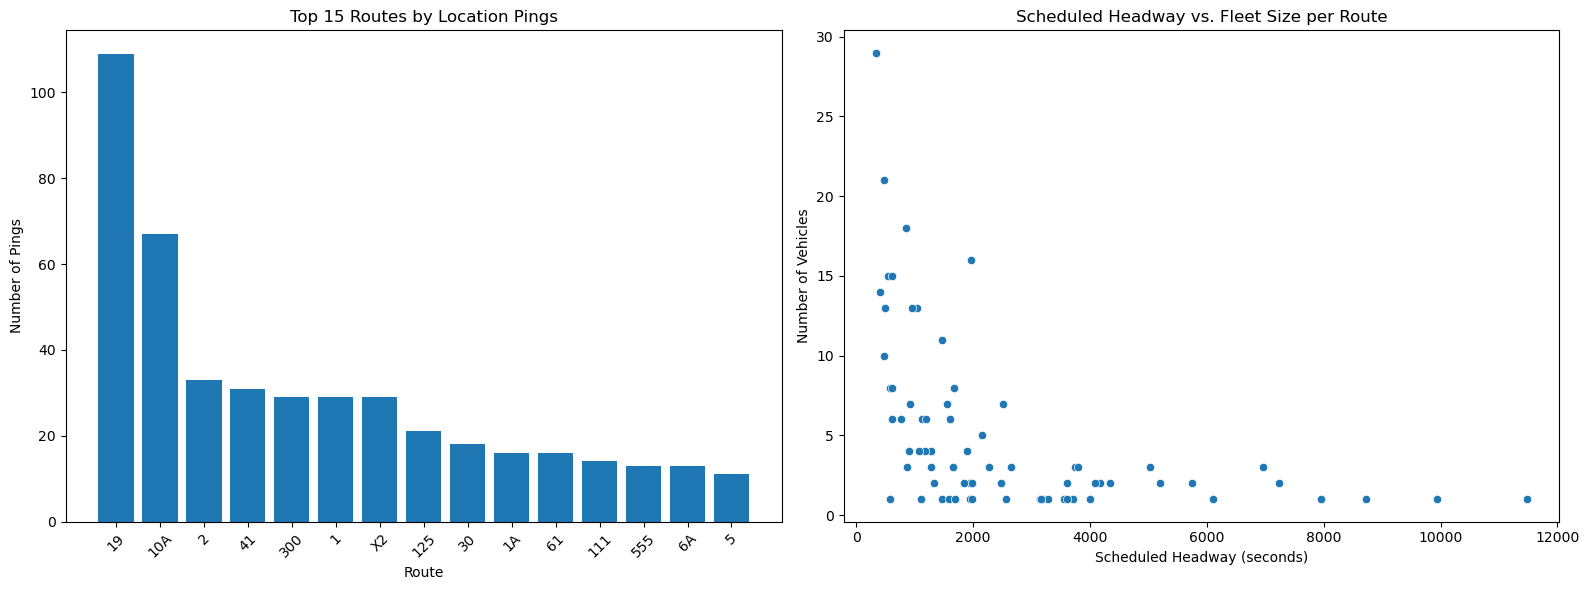

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

per_route_pdf = per_route_enriched.toPandas()


top_routes = per_route_pdf.sort_values(by="n_pings", ascending=False).head(15)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].bar(top_routes["line_ref"], top_routes["n_pings"])
axes[0].set_title("Top 15 Routes by Location Pings")
axes[0].set_xlabel("Route")
axes[0].set_ylabel("Number of Pings")
axes[0].tick_params(axis='x', rotation=45)

sns.scatterplot(
    data=per_route_pdf,
    x="scheduled_headway_sec",
    y="n_vehicles",
    ax=axes[1]
)

axes[1].set_title("Scheduled Headway vs. Fleet Size per Route")
axes[1].set_xlabel("Scheduled Headway (seconds)")
axes[1].set_ylabel("Number of Vehicles")

plt.tight_layout()

plt.savefig("figure_eda_route_summary.png", dpi=150)

plt.show()
